In [1]:
# ============================================
# K-MEANS CLUSTERING - CUSTOMER SEGMENTATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# 1. CREATE CUSTOMER DATASET
# ============================================

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Age": np.random.randint(18, 65, n),
    "AnnualIncome": np.random.randint(20000, 150000, n),
    "SpendingScore": np.random.randint(1, 101, n),
    "PurchasesPerYear": np.random.randint(1, 30, n)
})

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset created successfully!
Dataset shape: (500, 4)


,Age,AnnualIncome,SpendingScore,PurchasesPerYear
0,56,24000,56,11
1,46,90588,94,14
2,32,121042,63,4
3,60,113610,48,26
4,25,140420,61,26


In [3]:
# ============================================
# 2. DATA EXPLORATION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape:
(500, 4)

Column Names:
['Age', 'AnnualIncome', 'SpendingScore', 'PurchasesPerYear']

Data Types:
Age                 int64
AnnualIncome        int64
SpendingScore       int64
PurchasesPerYear    int64
dtype: object

Missing Values:
Age                 0
AnnualIncome        0
SpendingScore       0
PurchasesPerYear    0
dtype: int64

Basic Statistics:


,Age,AnnualIncome,SpendingScore,PurchasesPerYear
count,500.000000,500.00000,500.000000,500.000000
mean,41.278000,82395.20000,48.830000,15.104000
std,13.389072,37471.18879,29.228783,8.449377
min,18.000000,20384.00000,1.000000,1.000000
25%,30.000000,48225.25000,24.000000,8.000000
50%,42.000000,79097.00000,49.000000,15.000000
75%,52.000000,113636.00000,74.000000,23.000000
max,64.000000,149695.00000,100.000000,29.000000


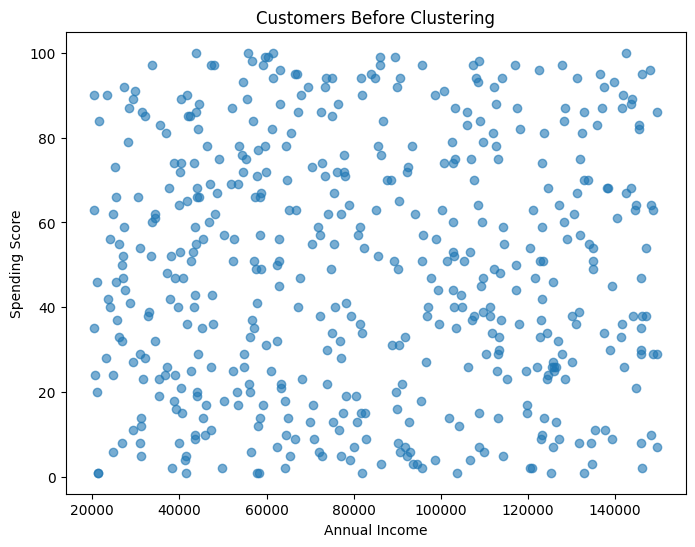

In [4]:
# ============================================
# 3. VISUALIZATION BEFORE CLUSTERING
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    alpha=0.6
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customers Before Clustering")

plt.show()

In [5]:
# ============================================
# 4. SELECT FEATURES
# ============================================

features = [
    "Age",
    "AnnualIncome",
    "SpendingScore",
    "PurchasesPerYear"
]

X = df[features]

print("Features used for clustering:")
print(features)

print("\nFeature shape:", X.shape)

Features used for clustering:
['Age', 'AnnualIncome', 'SpendingScore', 'PurchasesPerYear']

Feature shape: (500, 4)


In [6]:
# ============================================
# 5. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Features standardized successfully!
Scaled data shape: (500, 4)


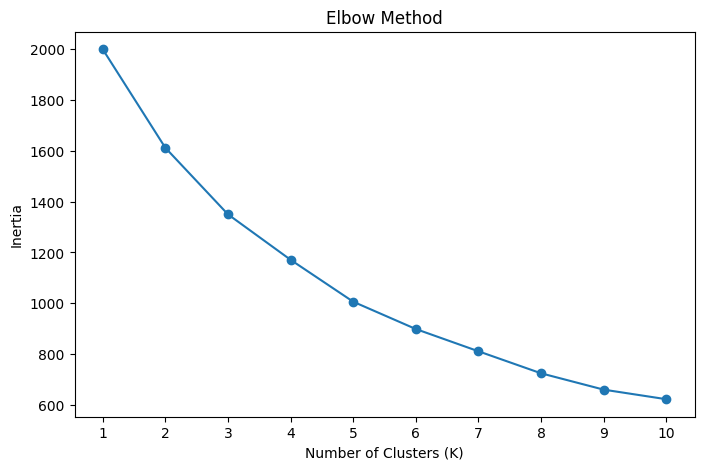

In [7]:
# ============================================
# 6. ELBOW METHOD
# ============================================

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))

plt.show()

In [8]:
# ============================================
# 7. TRAIN K-MEANS MODEL
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")
print("Number of clusters:", kmeans.n_clusters)

K-Means model trained successfully!
Number of clusters: 4


In [9]:
# ============================================
# 8. ADD CLUSTER LABELS
# ============================================

df["Cluster"] = clusters

print("Cluster labels added successfully!")

display(df.head(10))

Cluster labels added successfully!


,Age,AnnualIncome,SpendingScore,PurchasesPerYear,Cluster
0,56,24000,56,11,0
1,46,90588,94,14,3
2,32,121042,63,4,2
3,60,113610,48,26,1
4,25,140420,61,26,3
5,38,123691,81,29,1
6,56,126306,26,13,1
7,36,117856,36,2,2
8,40,58304,1,23,2
9,28,131783,8,5,2


Customers in each cluster:
Cluster
0    125
1    128
2    149
3     98
Name: count, dtype: int64


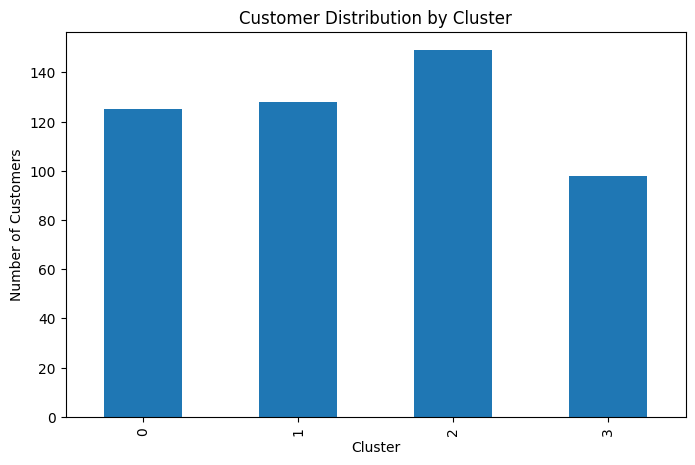

In [10]:
# ============================================
# 9. CLUSTER DISTRIBUTION
# ============================================

cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Cluster")

plt.show()

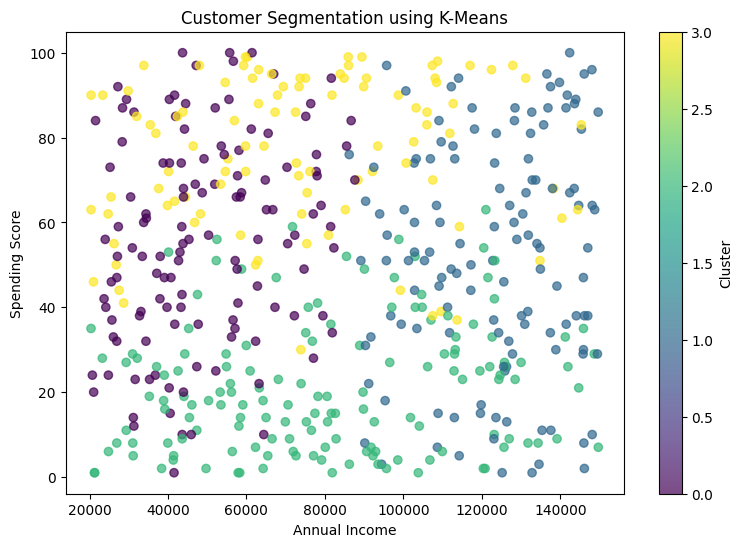

In [11]:
# ============================================
# 10. CUSTOMER SEGMENTS
# ============================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"],
    alpha=0.7
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.colorbar(label="Cluster")

plt.show()

In [12]:
# ============================================
# 11. CLUSTER CENTERS
# ============================================

centers_scaled = kmeans.cluster_centers_

centers_original = scaler.inverse_transform(
    centers_scaled
)

centers_df = pd.DataFrame(
    centers_original,
    columns=features
)

centers_df.index.name = "Cluster"

print("Cluster Centers:")
display(centers_df)

Cluster Centers:


,Age,AnnualIncome,SpendingScore,PurchasesPerYear
Cluster,,,,
0,52.032000,49319.224000,56.224000,16.368000
1,49.789062,122916.289062,52.281250,17.328125
2,33.778523,80867.510067,21.402685,10.382550
3,27.846939,73981.153061,76.591837,17.765306


In [13]:
# ============================================
# 12. CLUSTER PROFILE
# ============================================

cluster_profile = df.groupby("Cluster")[features].mean().round(2)

print("Customer Segment Profiles:")
display(cluster_profile)

Customer Segment Profiles:


,Age,AnnualIncome,SpendingScore,PurchasesPerYear
Cluster,,,,
0,52.03,49319.22,56.22,16.37
1,49.79,122916.29,52.28,17.33
2,33.78,80867.51,21.40,10.38
3,27.85,73981.15,76.59,17.77


In [14]:
# ============================================
# 13. NEW CUSTOMER SEGMENT
# ============================================

new_customer = pd.DataFrame({
    "Age": [28],
    "AnnualIncome": [80000],
    "SpendingScore": [75],
    "PurchasesPerYear": [18]
})

new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = kmeans.predict(
    new_customer_scaled
)[0]

print("New Customer:")
display(new_customer)

print("\nAssigned Cluster:", predicted_cluster)

New Customer:


,Age,AnnualIncome,SpendingScore,PurchasesPerYear
0,28,80000,75,18



Assigned Cluster: 3


In [15]:
# ============================================
# 14. FINAL SUMMARY
# ============================================

print("=" * 55)
print("K-MEANS CUSTOMER SEGMENTATION - FINAL SUMMARY")
print("=" * 55)

print("\nAlgorithm: K-Means Clustering")
print("Learning Type: Unsupervised Learning")
print("Number of Clusters:", kmeans.n_clusters)
print("Number of Customers:", len(df))

print("\nFeatures Used:")
for feature in features:
    print("-", feature)

print("\nCluster Sizes:")
print(cluster_counts)

print("\nCustomer segmentation completed successfully!")

K-MEANS CUSTOMER SEGMENTATION - FINAL SUMMARY

Algorithm: K-Means Clustering
Learning Type: Unsupervised Learning
Number of Clusters: 4
Number of Customers: 500

Features Used:
- Age
- AnnualIncome
- SpendingScore
- PurchasesPerYear

Cluster Sizes:
Cluster
0    125
1    128
2    149
3     98
Name: count, dtype: int64

Customer segmentation completed successfully!
